In [39]:
# SET UP: RUN ONCE THEN START THE CELLS WITH THEIR EXPLANATIONS
ensure_pkg <- function(pkg, bioc = FALSE) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    if (bioc) {
      if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")
      BiocManager::install(pkg, ask = FALSE, update = FALSE)
    } else {
      install.packages(pkg)
    }
  }
  suppressPackageStartupMessages(library(pkg, character.only = TRUE))
}

ensure_pkgs <- function() {
  ensure_pkg("GEOquery", bioc = TRUE)
  ensure_pkg("edgeR", bioc = TRUE)
  ensure_pkg("limma", bioc = TRUE)
  ensure_pkg("pheatmap", bioc = FALSE)
}

load_counts_matrix <- function(gse_id, base_dir = ".") {
  getGEOSuppFiles(gse_id, makeDirectory = TRUE, baseDir = base_dir)
  gz <- file.path(base_dir, gse_id, paste0(gse_id, "_LC_counts.tsv.gz"))
  if (!file.exists(gz)) {
    candidates <- list.files(file.path(base_dir, gse_id), pattern = "LC_counts\\.tsv\\.gz$", full.names = TRUE)
    if (length(candidates) == 0) stop("Counts file not found in: ", file.path(base_dir, gse_id))
    gz <- candidates[1]
  }
  df <- read.delim(gzfile(gz), header = TRUE, sep = "\t", check.names = FALSE, stringsAsFactors = FALSE)
  gene_ids <- make.unique(as.character(df[[1]]))
  mat <- as.matrix(df[, -1, drop = FALSE])
  rownames(mat) <- gene_ids
  suppressWarnings(mode(mat) <- "numeric")
  mat
}

get_pheno <- function(gse_id) {
  gse_obj <- getGEO(gse_id, GSEMatrix = TRUE)
  gse <- if (is.list(gse_obj)) gse_obj[[1]] else gse_obj
  pData(gse)
}

extract_sample_id_from_pheno <- function(pheno, sample_names) {
  char_cols <- grep("^characteristics_ch1", colnames(pheno), value = TRUE)
  sample_id <- rep(NA_character_, nrow(pheno))

  if (length(char_cols) > 0) {
    for (i in seq_len(nrow(pheno))) {
      row_vals <- as.character(unlist(pheno[i, char_cols, drop = FALSE]))
      hits <- grep("sample\\s*id\\s*[:=]", row_vals, ignore.case = TRUE, value = TRUE)
      if (length(hits) > 0) {
        x <- sub(".*sample\\s*id\\s*[:=]\\s*", "", hits[1], ignore.case = TRUE)
        sample_id[i] <- trimws(x)
      }
    }
  }

  if (any(is.na(sample_id))) {
    for (i in which(is.na(sample_id))) {
      txt <- paste(c(pheno$title[i], as.character(unlist(pheno[i, char_cols, drop = FALSE]))), collapse = " | ")
      m <- sample_names[sapply(sample_names, function(s) grepl(s, txt, fixed = TRUE))]
      if (length(m) >= 1) sample_id[i] <- m[1]
    }
  }

  if (any(is.na(sample_id))) {
    for (i in which(is.na(sample_id))) {
      txt <- paste(c(pheno$title[i], as.character(unlist(pheno[i, char_cols, drop = FALSE]))), collapse = " | ")
      m <- regmatches(txt, regexpr("(CCI\\d+|HP\\d+|S\\d+_\\d+)", txt))
      if (!is.na(m) && nchar(m) > 0) sample_id[i] <- m
    }
  }

  sample_id
}

build_metadata <- function(pheno, expr_mat) {
  if (!("title" %in% colnames(pheno))) stop("Column 'title' not found in phenotype data.")
  group <- ifelse(grepl("Healthy\\s*Control", pheno$title, ignore.case = TRUE), "Control", "ME_CFS")
  group <- factor(group, levels = c("Control", "ME_CFS"))

  sample_id <- extract_sample_id_from_pheno(pheno, colnames(expr_mat))
  if (any(is.na(sample_id))) stop("Could not extract sample_id for some samples.")

  md <- data.frame(sample_id = sample_id, group = group, stringsAsFactors = FALSE)
  rownames(md) <- md$sample_id
  md
}

align_counts_metadata <- function(expr_mat, metadata) {
  missing_in_counts <- setdiff(metadata$sample_id, colnames(expr_mat))
  extra_in_counts <- setdiff(colnames(expr_mat), metadata$sample_id)
  if (length(missing_in_counts) > 0 || length(extra_in_counts) > 0) {
    stop("Mismatch between metadata sample_id and counts columns.")
  }
  expr_mat <- expr_mat[, metadata$sample_id, drop = FALSE]
  list(expr_mat = expr_mat, metadata = metadata)
}

validate_alignment <- function(counts, coldata) {
  stopifnot(identical(colnames(counts), rownames(coldata)))
  invisible(TRUE)
}

ensure_pkgs()


Using locally cached version of supplementary file(s) GSE270045 found here:
./GSE270045/GSE270045_LC_counts.tsv.gz 



Loaded expression matrix (genes x samples):
[1] 28889    36

[Item 1] dim(expr_mat) = 28889 genes x 36 samples

[Item 2] First 5 rows x first 5 columns:
           CCI031    CCI041     CCI042    CCI050   CCI064
5S_rRNA  0.000000   0.00000   0.000000   0.00000  0.00000
A1BG    92.103500 105.87411  85.063750 110.46840 52.29464
A1CF     9.103139  25.11204   8.072486  12.13559 10.09736
A2M     60.021740 125.18732 129.918560 145.73940 98.72202
A2ML1   13.652440  39.72340  21.217640  33.96565  7.28073

[Item 2] 5S_rRNA values across samples:
  CCI031   CCI041   CCI042   CCI050   CCI064   CCI069   CCI077   CCI088 
0.000000 0.000000 0.000000 0.000000 0.000000 1.011600 0.000000 0.000000 
   CCI12   CCI136   CCI138    CCI58    CCI93   HP1193   HP1194   HP1301 
0.000000 1.156240 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 
   HP851  S013_11  S014_11  S016_11  S020_11  S023_11  S024_11  S025_11 
0.000000 0.000000 0.000000 0.000000 1.254030 0.000000 0.000000 0.000000 
 S026_11  S027_11  S

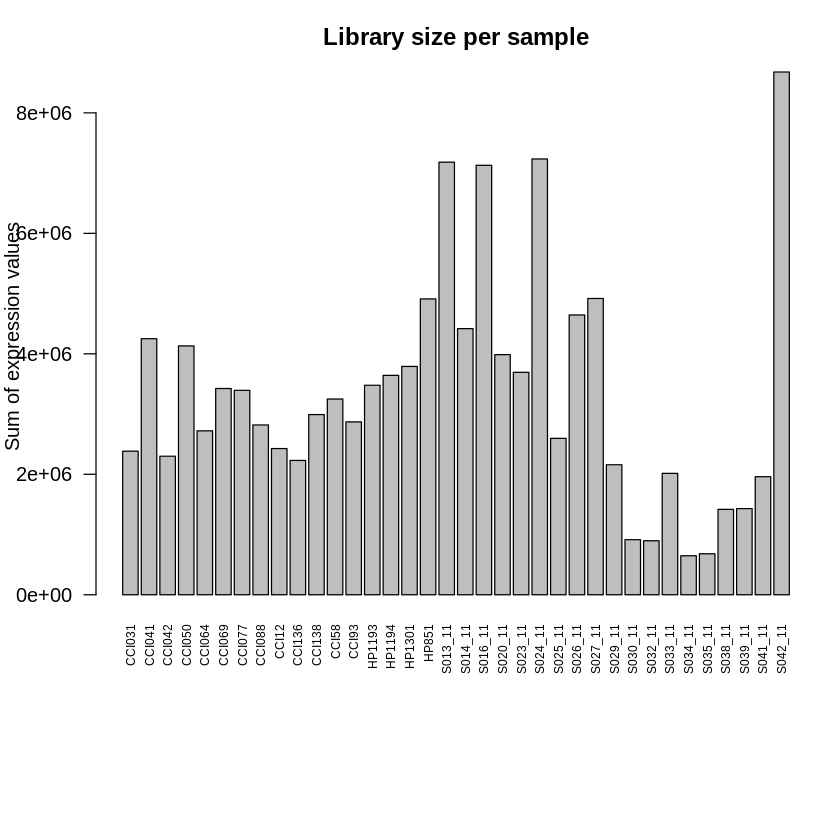

In [40]:
# SECTION ONE

gse_id <- "GSE270045"
expr_mat <- load_counts_matrix(gse_id)

cat("Loaded expression matrix (genes x samples):\n")
print(dim(expr_mat))

dims <- dim(expr_mat)
cat("\n[Item 1] dim(expr_mat) =", dims[1], "genes x", dims[2], "samples\n")


cat("\n[Item 2] First 5 rows x first 5 columns:\n")
print(expr_mat[1:5, 1:5])

target_gene <- "5S_rRNA"
fiveS <- NULL
if (target_gene %in% rownames(expr_mat)) {
  fiveS <- expr_mat[target_gene, ]
} else {
  hits <- grep(target_gene, rownames(expr_mat), value = TRUE)
  if (length(hits) > 0) fiveS <- expr_mat[hits[1], ]
}

if (!is.null(fiveS)) {
  cat("\n[Item 2] 5S_rRNA values across samples:\n")
  print(fiveS)
  cat("\nSummary of 5S_rRNA:\n")
  print(summary(fiveS))
}

na_count <- sum(is.na(expr_mat))
has_neg <- any(expr_mat < 0, na.rm = TRUE)
mat_range <- range(expr_mat, na.rm = TRUE)

cat("\n[Item 3] NA count:", na_count, "\n")
cat("[Item 3] Any negative values?", has_neg, "\n")
cat("[Item 3] Min–Max:\n")
print(mat_range)

is_integerish <- all(abs(expr_mat - round(expr_mat)) < 1e-6, na.rm = TRUE)
any_decimal <- any(abs(expr_mat - floor(expr_mat)) > 1e-6, na.rm = TRUE)

cat("\n[Item 4] Integer-like values?", is_integerish, "\n")
cat("[Item 4] Any decimals present?", any_decimal, "\n")
cat("[Item 4] Range:", mat_range[1], "to", mat_range[2], "\n")

library_size <- colSums(expr_mat, na.rm = TRUE)

cat("\n[Item 5] Library size summary:\n")
print(summary(library_size))
cat("\n[Item 5] Top 5 largest library sizes:\n")
print(sort(library_size, decreasing = TRUE)[1:5])
cat("\n[Item 5] Top 5 smallest library sizes:\n")
print(sort(library_size, decreasing = FALSE)[1:5])
cat("\n[Item 5] Max/Min library size ratio:", max(library_size) / min(library_size), "\n")
op <- par(no.readonly = TRUE)
par(mar = c(10, 4, 3, 1))
barplot(library_size, las = 2, cex.names = 0.6, main = "Library size per sample", ylab = "Sum of expression values")
par(op)
zero_genes <- rowSums(expr_mat, na.rm = TRUE) == 0
cat("\n[Item 6] Genes with ALL-ZERO values:", sum(zero_genes), "\n")
qs <- quantile(library_size, probs = c(0.25, 0.75), na.rm = TRUE)
iqr_val <- qs[2] - qs[1]
low_thr <- qs[1] - 1.5 * iqr_val
high_thr <- qs[2] + 1.5 * iqr_val
outlier_samples <- names(library_size)[library_size < low_thr | library_size > high_thr]

cat("[Item 6] Potential library-size outlier samples (IQR rule):\n")
if (length(outlier_samples) == 0) {
  cat("None detected.\n")
} else {
  print(library_size[outlier_samples])
}

total_counts_per_gene <- rowSums(expr_mat, na.rm = TRUE)
cat("\n[Item 6] Top 10 genes by total expression:\n")
print(head(sort(total_counts_per_gene, decreasing = TRUE), 10))

In [41]:
gse_id <- "GSE270045"
pheno <- get_pheno(gse_id)

cat("Phenotype table dimensions (samples x columns):\n")
print(dim(pheno))

show_cols <- intersect(c("title", "geo_accession"), colnames(pheno))
char_cols <- grep("^characteristics_ch1", colnames(pheno), value = TRUE)
preview_cols <- unique(c(show_cols, char_cols))
preview_cols <- preview_cols[1:min(8, length(preview_cols))]
cat("\nPreview of selected columns:\n")
print(head(pheno[, preview_cols, drop = FALSE]))

metadata <- build_metadata(pheno, expr_mat)

cat("\nGroup counts (table(group)):\n")
print(table(metadata$group))

cat("\nMetadata preview:\n")
print(head(metadata))

tmp <- align_counts_metadata(expr_mat, metadata)
expr_mat <- tmp$expr_mat
metadata <- tmp$metadata

cat("\nCheck: do sample_id values match expr_mat column names?\n")
print(setdiff(metadata$sample_id, colnames(expr_mat)))
print(setdiff(colnames(expr_mat), metadata$sample_id))

counts <- expr_mat
coldata <- metadata
validate_alignment(counts, coldata)

cat("\nFinal metadata dimensions:\n")
print(dim(coldata))
cat("Row names equal sample_id? ", identical(rownames(coldata), coldata$sample_id), "\n", sep = "")


Found 1 file(s)

GSE270045_series_matrix.txt.gz

Using locally cached version: /tmp/Rtmph0oYQV/GSE270045_series_matrix.txt.gz

Using locally cached version of GPL34284 found here:
/tmp/Rtmph0oYQV/GPL34284.soft.gz 



Phenotype table dimensions (samples x columns):
[1] 36 45

Preview of selected columns:
                       title geo_accession characteristics_ch1
GSM8333270 Healthy Control 1    GSM8333270 tissue: whole blood
GSM8333271 Healthy Control 2    GSM8333271 tissue: whole blood
GSM8333272 Healthy Control 3    GSM8333272 tissue: whole blood
GSM8333273 Healthy Control 4    GSM8333273 tissue: whole blood
GSM8333274 Healthy Control 5    GSM8333274 tissue: whole blood
GSM8333275 Healthy Control 6    GSM8333275 tissue: whole blood
            characteristics_ch1.1 characteristics_ch1.2 characteristics_ch1.3
GSM8333270 cell type: whole blood         treatment: No     sample id: CCI031
GSM8333271 cell type: whole blood         treatment: No     sample id: CCI041
GSM8333272 cell type: whole blood         treatment: No     sample id: CCI042
GSM8333273 cell type: whole blood         treatment: No     sample id: CCI050
GSM8333274 cell type: whole blood         treatment: No     sample id: CCI064
GSM

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
    0.000     0.000     4.622   116.946    60.607 95726.724 

Range:
[1]     0.00 95726.72

Any NA?
[1] FALSE

Any negative?
[1] FALSE
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 647288 2212155 3120772 3378446 4161133 8678469 


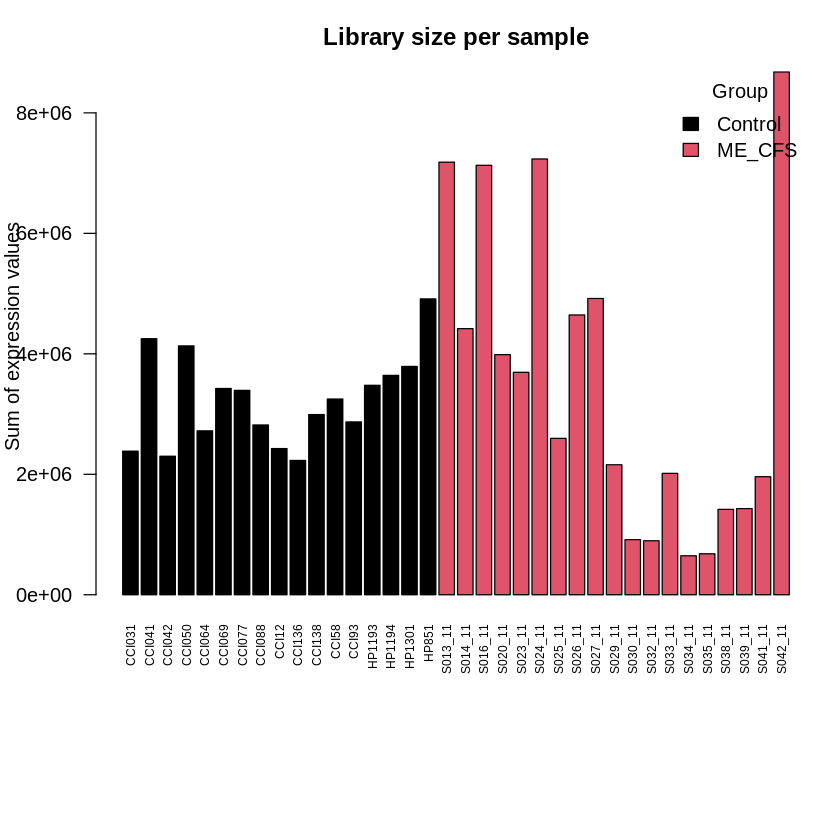

Note: counts have decimals; rounding for edgeR/voom plotting step.



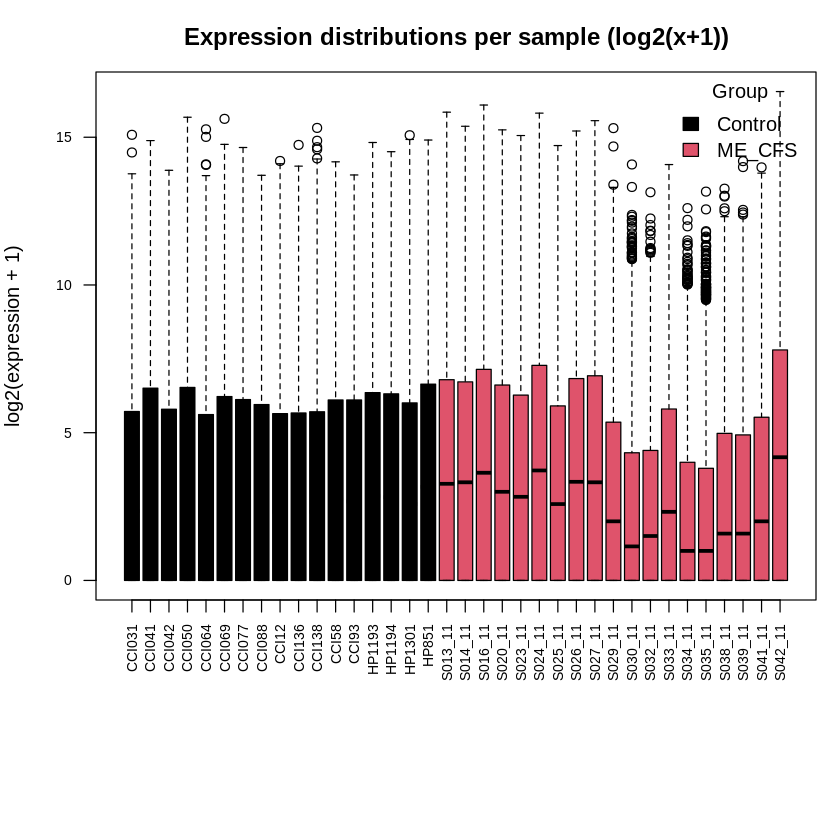

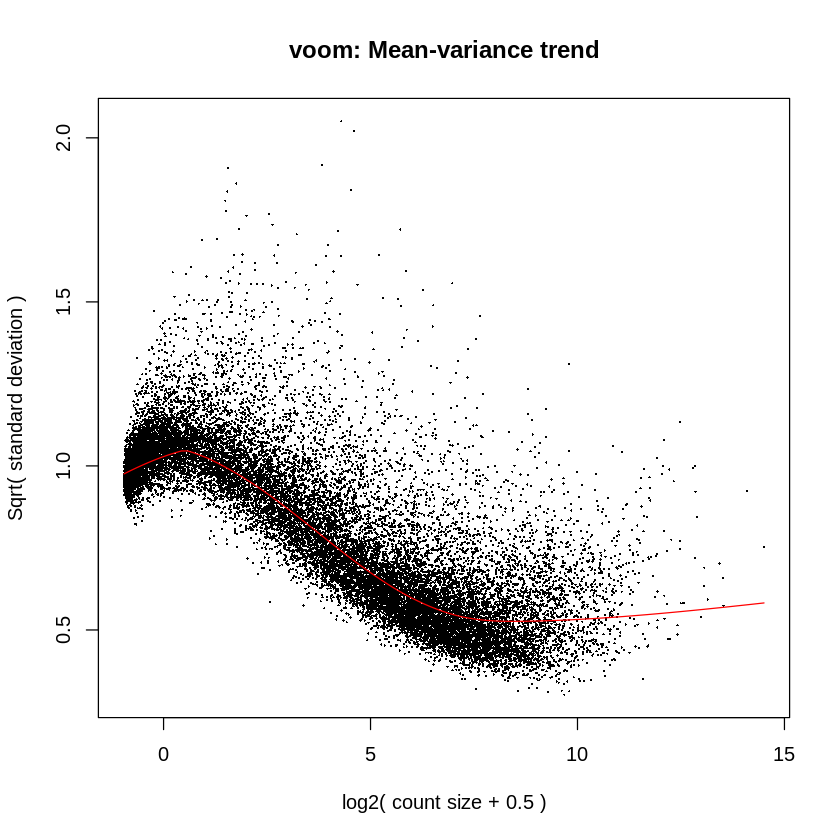

In [34]:
validate_alignment(counts, coldata)

print(summary(as.vector(counts)))
cat("\nRange:\n"); print(range(counts, na.rm = TRUE))
cat("\nAny NA?\n"); print(any(is.na(counts)))
cat("\nAny negative?\n"); print(any(counts < 0, na.rm = TRUE))

library_size <- colSums(counts, na.rm = TRUE)
print(summary(library_size))

grp <- factor(coldata$group, levels = c("Control", "ME_CFS"))
grp_levels <- levels(grp)
grp_cols <- setNames(seq_along(grp_levels), grp_levels)

op <- par(no.readonly = TRUE)
par(mar = c(10, 4, 3, 1))
barplot(library_size, las = 2, cex.names = 0.6, main = "Library size per sample", ylab = "Sum of expression values", col = grp_cols[as.character(grp)])
legend("topright", legend = grp_levels, fill = grp_cols[grp_levels], bty = "n", title = "Group")
par(op)

log_counts <- log2(counts + 1)

op <- par(no.readonly = TRUE)
par(mar = c(10, 4, 3, 1))
boxplot(log_counts, las = 2, cex.axis = 0.7, main = "Expression distributions per sample (log2(x+1))", ylab = "log2(expression + 1)", col = grp_cols[as.character(grp)])
legend("topright", legend = grp_levels, fill = grp_cols[grp_levels], bty = "n", title = "Group")
par(op)

counts_for_edger <- counts
if (!all(abs(counts_for_edger - round(counts_for_edger)) < 1e-6, na.rm = TRUE)) {
  message("Note: counts have decimals; rounding for edgeR/voom plotting step.")
  counts_for_edger <- round(counts_for_edger)
}

dge <- edgeR::DGEList(counts = counts_for_edger, group = grp)
dge <- edgeR::calcNormFactors(dge)
design <- model.matrix(~ grp)
v_tmp <- limma::voom(dge, design = design, plot = TRUE)


Genes kept after low-variance filtering: 24247 of 28889 

% variance explained:
PC1: 59.9 %
PC2: 4.54 %
PC3: 3.44 %


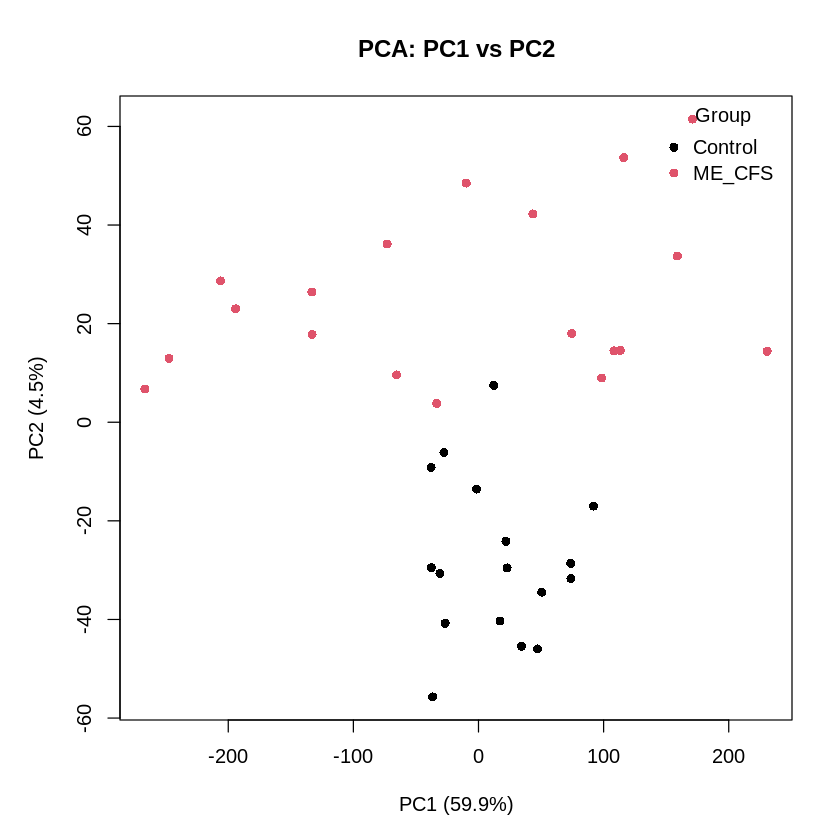

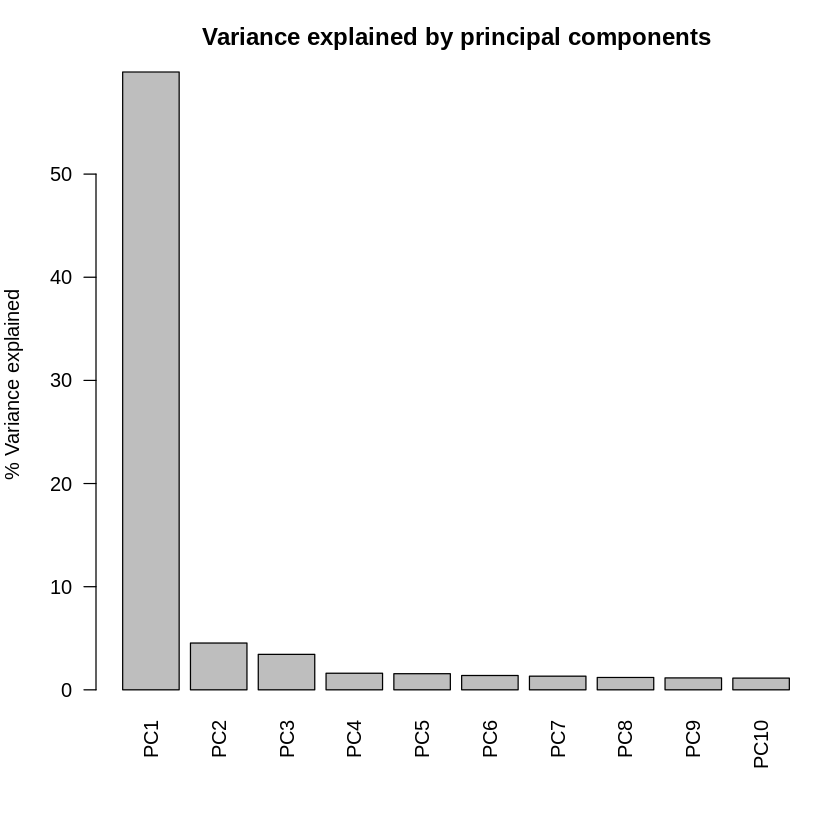

In [35]:
validate_alignment(counts, coldata)

log_counts <- log2(counts + 1)
gene_var <- apply(log_counts, 1, var, na.rm = TRUE)
var_cut <- quantile(gene_var, probs = 0.10, na.rm = TRUE)
keep_genes <- gene_var > var_cut
log_counts_f <- log_counts[keep_genes, , drop = FALSE]

cat("Genes kept after low-variance filtering:", sum(keep_genes), "of", length(keep_genes), "\n")

pca <- prcomp(t(log_counts_f), center = TRUE, scale. = FALSE)
pve <- (pca$sdev^2) / sum(pca$sdev^2) * 100

cat("\n% variance explained:\n")
cat("PC1:", round(pve[1], 2), "%\n")
cat("PC2:", round(pve[2], 2), "%\n")
cat("PC3:", round(pve[3], 2), "%\n")

pca_df <- data.frame(sample_id = rownames(pca$x), PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = coldata[rownames(pca$x), "group"])
grp <- factor(pca_df$group, levels = c("Control", "ME_CFS"))
grp_levels <- levels(grp)
grp_cols <- setNames(seq_along(grp_levels), grp_levels)

op <- par(no.readonly = TRUE)
par(mar = c(5, 5, 4, 2))
plot(pca_df$PC1, pca_df$PC2, xlab = paste0("PC1 (", round(pve[1], 1), "%)"),
                                          ylab = paste0("PC2 (", round(pve[2], 1), "%)"), main = "PCA: PC1 vs PC2", pch = 16, col = grp_cols[as.character(grp)])
legend("topright", legend = grp_levels, col = grp_cols[grp_levels], pch = 16, bty = "n", title = "Group")
par(op)

n_pcs <- min(10, length(pve))
op <- par(no.readonly = TRUE)
par(mar = c(6, 4, 3, 1))
barplot(pve[1:n_pcs], names.arg = paste0("PC", 1:n_pcs), las = 2, ylab = "% Variance explained", main = "Variance explained by principal components")
par(op)


Note: counts are non-integer; rounding for edgeR/voom pipeline.



Genes kept after filterByExpr: 13135 of 28889 

Top 10 DE genes (by adj.P.Val):
             gene      logFC  AveExpr      P.Value    adj.P.Val        B
TAF1D       TAF1D  0.9633645 6.205198 7.032768e-16 9.048835e-12 26.02114
ZBTB7A     ZBTB7A -0.7244328 7.490465 1.377820e-15 9.048835e-12 25.34364
SCAF1       SCAF1 -0.9887511 6.493078 2.421169e-15 1.060069e-11 24.82173
MAP1S       MAP1S -0.9085257 6.112553 7.307425e-15 1.780079e-11 23.74931
SLC38A10 SLC38A10 -0.8026204 7.435993 7.398629e-15 1.780079e-11 23.71897
PLEC         PLEC -0.9802310 9.253890 8.131307e-15 1.780079e-11 23.48570
FBRSL1     FBRSL1 -0.9181409 7.115005 1.284144e-14 2.228698e-11 23.19198
HCFC1       HCFC1 -0.9021388 7.325981 1.357411e-14 2.228698e-11 23.13257
CIC           CIC -0.8375012 7.763934 1.954889e-14 2.853052e-11 22.76367
MFSD12     MFSD12 -0.7401984 6.517466 2.747606e-14 3.453307e-11 22.46115

Significant genes (adj.P.Val < 0.05 & |logFC| > 1): 174 


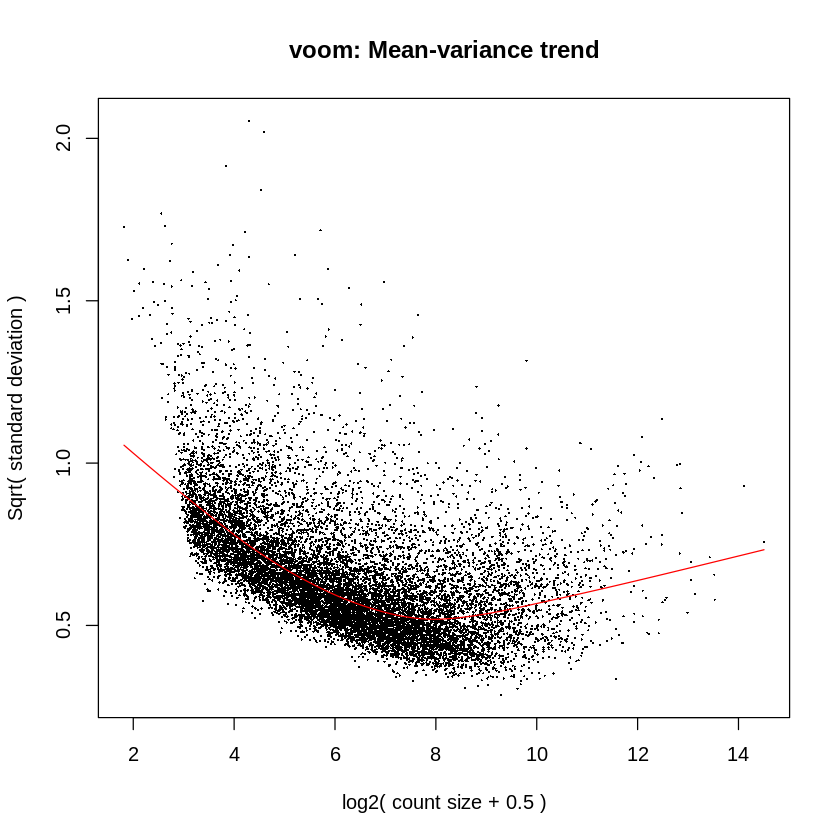

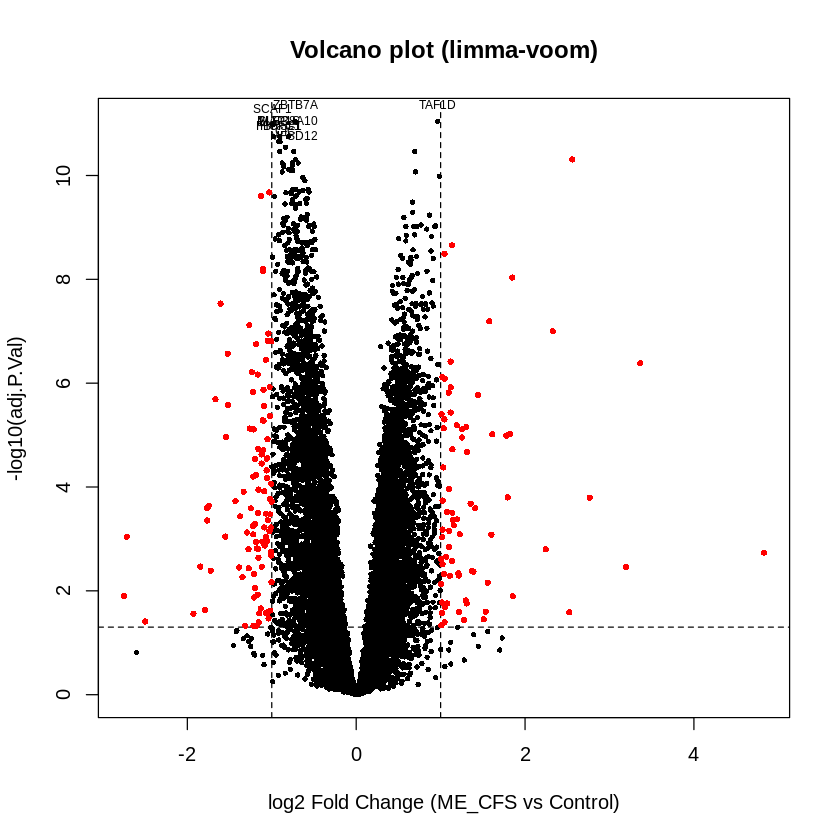

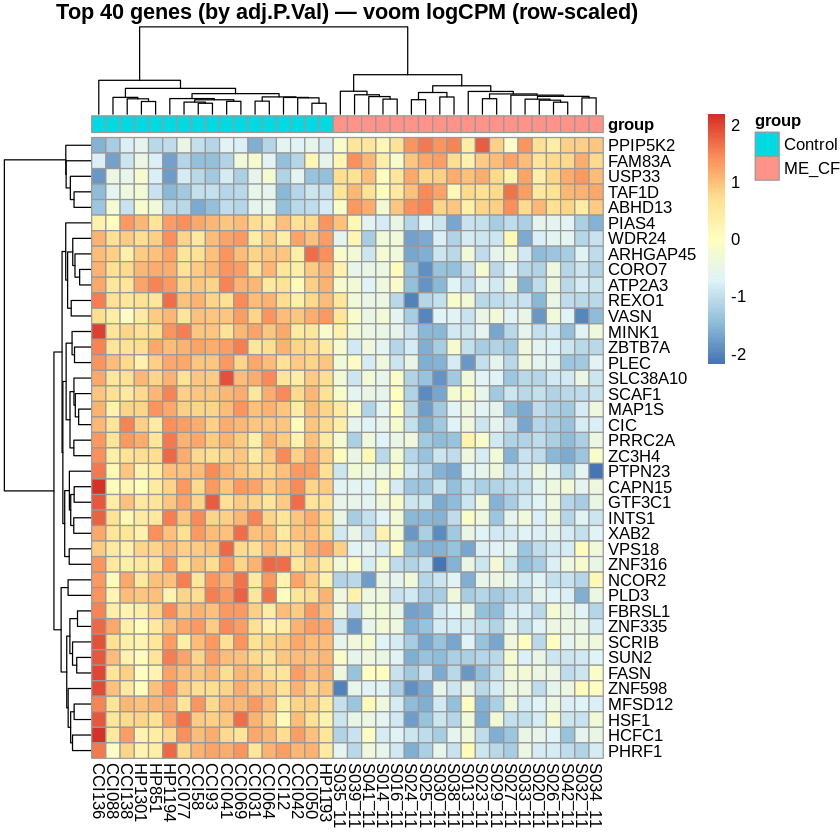

In [36]:
validate_alignment(counts, coldata)

grp <- factor(coldata$group, levels = c("Control", "ME_CFS"))
counts_for_edger <- counts
if (!all(abs(counts_for_edger - round(counts_for_edger)) < 1e-6, na.rm = TRUE)) {
  message("Note: counts are non-integer; rounding for edgeR/voom pipeline.")
  counts_for_edger <- round(counts_for_edger)
}

dge <- edgeR::DGEList(counts = counts_for_edger, group = grp)
dge <- edgeR::calcNormFactors(dge)

design <- model.matrix(~ grp)
keep <- edgeR::filterByExpr(dge, design = design)
dge <- dge[keep, , keep.lib.sizes = FALSE]
dge <- edgeR::calcNormFactors(dge)

cat("Genes kept after filterByExpr:", sum(keep), "of", length(keep), "\n")

v <- limma::voom(dge, design = design, plot = TRUE)
fit <- limma::lmFit(v, design)
fit <- limma::eBayes(fit)

coef_name <- "grpME_CFS"
if (!(coef_name %in% colnames(fit$coefficients))) stop("Coefficient not found: ", coef_name)

res <- limma::topTable(fit, coef = coef_name, number = Inf, sort.by = "P")
res$gene <- rownames(res)

cat("\nTop 10 DE genes (by adj.P.Val):\n")
print(res[order(res$adj.P.Val), c("gene","logFC","AveExpr","P.Value","adj.P.Val","B")][1:10, ])

sig <- (res$adj.P.Val < 0.05) & (abs(res$logFC) > 1)
cat("\nSignificant genes (adj.P.Val < 0.05 & |logFC| > 1):", sum(sig), "\n")

x <- res$logFC
y <- -log10(res$adj.P.Val)

plot(x, y, pch = 16, cex = 0.6, xlab = "log2 Fold Change (ME_CFS vs Control)", ylab = "-log10(adj.P.Val)", main = "Volcano plot (limma-voom)")
abline(v = c(-1, 1), lty = 2)
abline(h = -log10(0.05), lty = 2)
points(x[sig], y[sig], pch = 16, cex = 0.7, col = "red")

label_n <- 10
top_to_label <- head(order(res$adj.P.Val), label_n)
text(x[top_to_label], y[top_to_label], labels = res$gene[top_to_label], pos = 3, cex = 0.6)

top_n <- 40
top_genes <- res$gene[order(res$adj.P.Val)][1:top_n]
mat_heat <- v$E[top_genes, , drop = FALSE]
ann_col <- data.frame(group = grp)
rownames(ann_col) <- rownames(coldata)

pheatmap::pheatmap(mat_heat, annotation_col = ann_col, show_colnames = TRUE, show_rownames = TRUE,
                   scale = "row", main = paste0("Top ", top_n, " genes (by adj.P.Val) — voom logCPM (row-scaled)"))
